# 7. Moving Beyond Linearity

In [1]:
import numpy as np
from matplotlib.pyplot import subplots

import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (summarize,poly,ModelSpec as MS)
from statsmodels.stats.anova import anova_lm

from pygam import (s as s_gam, l as l_gam, f as f_gam,LinearGAM,LogisticGAM)

from ISLP.transforms import (BSpline,NaturalSpline)
from ISLP.models import bs,ns
from ISLP.pygam import (approx_lam, degrees_of_freedom, plot as plot_gam, anova as anova_gam)

In [3]:
Wage = load_data('Wage')
y = Wage['wage']
age = Wage['age']

In [6]:
poly_age = MS([poly('age',degree=4)]).fit(Wage)
M = sm.OLS(y,poly_age.transform(Wage)).fit()
M.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     70.69
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           2.77e-57
Time:                        08:12:03   Log-Likelihood:                -15315.
No. Observations:                3000   AIC:                         3.064e+04
Df Residuals:                    2995   BIC:                         3.067e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                111.7036      0.729    153.283      0.000     110.275     113.132
poly(age, degree=4)[0]   447.0679     39.915     11.201      0.000     368.805     525.331
poly(age, degree=4)[1]  -478.3158     39.915    -11.983      0.000    -556.579    -400.053
poly(age, degree=4)[2]   125.5217     39.915      3.145      0.002      47.259     203.785
poly(age, degree=4)[3]   -77.9112     39.915     -1.952      0.051    -156.174       0.352
==============================================================================
Omnibus:                     1097.594   Durbin-Watson:                   1.960
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4965.521
Skew:                           1.722   Prob(JB):                         0.00
Kurtosis:                       8.279   Cond. No.                         54.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
import pandas as pd
age_grid = np.linspace(age.min(),age.max(),100)
age_df = pd.DataFrame({'age':age_grid})

In [8]:
def plot_wage_fit(age_df,basis,title):
    X = basis.transform(Wage)
    Xnew = basis.transform(age_df)
    M = sm.OLS(y,X).fit()
    preds = M.get_prediction(Xnew)
    bands = preds.conf_int(alpha=0.05)
    fig,ax = subplots(figsize=(8,8))
    ax.scatter(age,y,facecolor='gray',alpha=0.5)

    for val, ls in zip([preds.predicted_mean,bands[:,0],bands[:,1],['b','r--','r--']]):
        ax.plot(age_df.values,val,ls,linewidth=3)
    ax.set_title(title,fontsize=20)
    ax.set_xlabel("Age",fontsize=20)
    ax.set_ylabel('Wage',fontsize=20)
    return ax


ValueError: not enough values to unpack (expected 2, got 1)

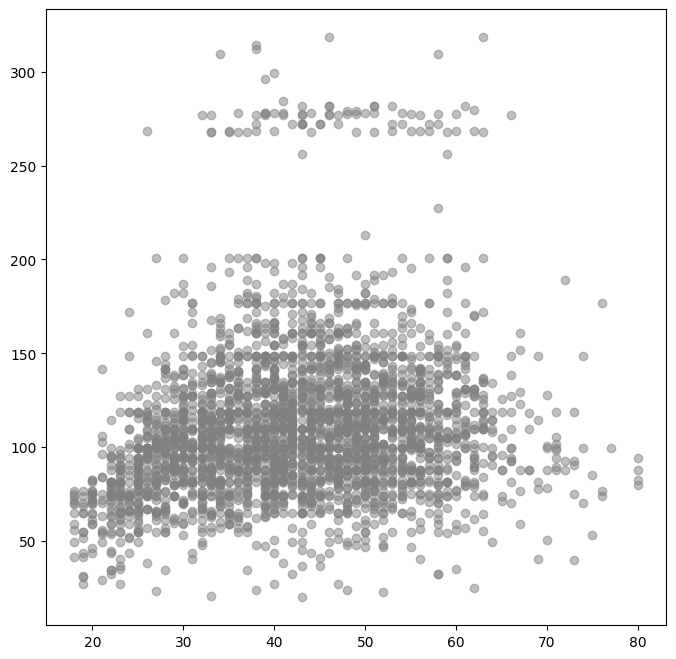

In [9]:
plot_wage_fit(age_df,poly_age,'Degree-4 Polynomial')

In [10]:
models = [MS([poly('age',degree=d)]) for d in range(1,6)]

Xs = [model.fit_transform(Wage) for model in models]
anova_lm(*[sm.OLS(y,X_).fit() for X_ in Xs])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0,5.022216e+06,0.0,NaN,NaN,NaN
1,2997.0,4.793430e+06,1.0,228786.010128,143.593107,2.363850e-32
2,2996.0,4.777674e+06,1.0,15755.693664,9.888756,1.679202e-03
3,2995.0,4.771604e+06,1.0,6070.152124,3.809813,5.104620e-02
4,2994.0,4.770322e+06,1.0,1282.563017,0.804976,3.696820e-01


In [11]:
summarize(M)

,coef,std err,t,P>|t|
intercept,111.7036,0.729,153.283,0.000
"poly(age, degree=4)[0]",447.0679,39.915,11.201,0.000
"poly(age, degree=4)[1]",-478.3158,39.915,-11.983,0.000
"poly(age, degree=4)[2]",125.5217,39.915,3.145,0.002
"poly(age, degree=4)[3]",-77.9112,39.915,-1.952,0.051


In [13]:
models = [MS(['education',poly('age',degree=d)]) for d in range(1,4)]
XEs = [model.fit_transform(Wage) for model in models]
anova_lm(*[sm.OLS(y,X_).fit() for X_ in XEs])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2997.0,3.902335e+06,0.0,NaN,NaN,NaN
1,2996.0,3.759472e+06,1.0,142862.701185,113.991883,3.838075e-26
2,2995.0,3.753546e+06,1.0,5926.207070,4.728593,2.974318e-02
